Import dependencies/libraries and the dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

Define the features (X) and the target (y)

In [4]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split the dataset into 80% training and 20% test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=111)

Train a Decision Tree classifier and make the predictons

In [23]:
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)
    
# Make predictions
y_pred = clf.predict(X_test)

Compute accuracy and classification report of the predictions against the testing data
Additionally, measure metrics such as MAE, MSE, RMSE and R^2

In [24]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Accuracy: 0.8743
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      4225
           1       0.87      0.88      0.87      4175

    accuracy                           0.87      8400
   macro avg       0.87      0.87      0.87      8400
weighted avg       0.87      0.87      0.87      8400

Mean Absolute Error (MAE): 0.1257
Mean Squared Error (MSE): 0.1257
Root Mean Squared Error (RMSE): 0.3546
R² Score: 0.4971


Confusion Matrix Visulisation:
Create a heatmap to visualise the confusion matrix. Shows how many instances were correctly or incorrectly classified

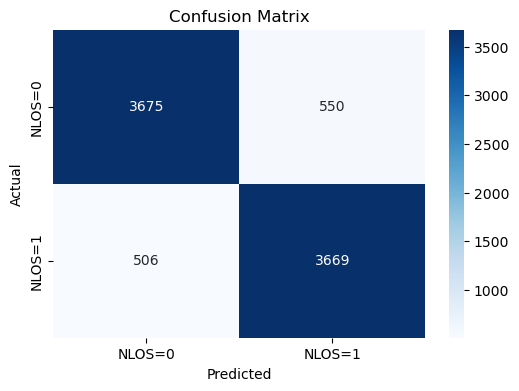

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance Visualisation:
Shows which features are most important in the decision tree model. Higher values indicate a stronger impact on predictions.

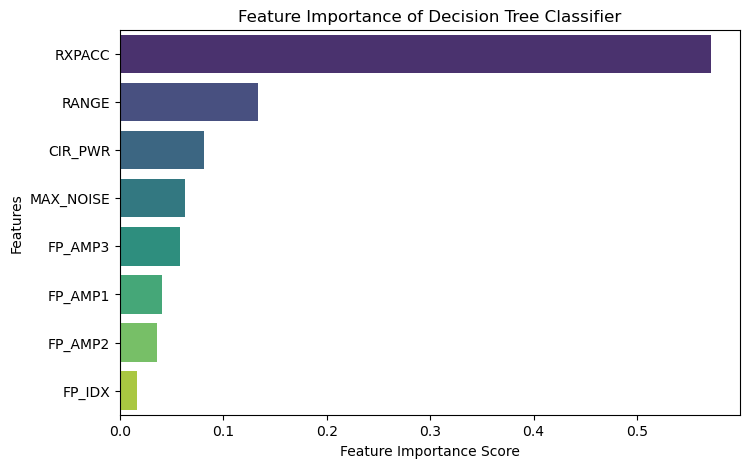

In [26]:
feature_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance.index, palette="viridis", legend=False)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance of Decision Tree Classifier")
plt.show()

Visualise the decision tree (only to 2 levels of depth as example)

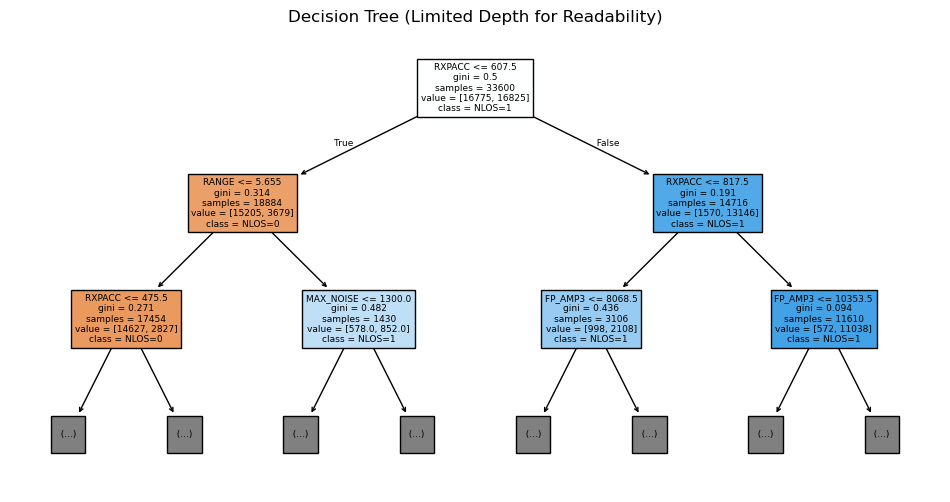

In [27]:
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["NLOS=0", "NLOS=1"], filled=True, max_depth=2)
plt.title("Decision Tree (Limited Depth for Readability)")
plt.show()